# COMP662 - Tutorial 7
# Transformers: Attention, a Mini Transformer, and Fine-tuning

Lincoln University, Centre for Geospatial and Computing Technologies.

Generative AI course. This tutorial goes with the *Transformers* lecture.

---

### What you will learn
By the end of this tutorial you should be able to:
1. Explain **token embeddings** and **positional encoding**, and why a transformer needs both.
2. Implement **scaled dot-product self-attention** from scratch, and read an attention heatmap.
3. Extend single-head attention to **multi-head attention**, and see what different heads pick up.
4. Assemble a small transformer block with **residual connections** and **layer normalisation**.
5. Train a mini transformer with **masked-token prediction** (the same idea behind BERT).
6. **Load a pretrained transformer and modify it**: swap its prediction head for a classification
   head and fine-tune it on a new task.
7. (Part 2, on your own) Fine-tune the same pretrained encoder on a **different** classification task.

### How this tutorial is structured
Part 1 is a guided walk-through (about 1.5 hours): read each explanation, then run the cell under it.
Part 2 is a short individual exercise (about 30 to 45 minutes) with hints but no full solution.

Tutorial 3 has the step-by-step guide for running this on a free Kaggle or Colab GPU, if you want one.
Everything here is small enough to run comfortably on a laptop CPU too.

---
# Part 1 - Guided walk-through (about 1.5 hours)

## Section 0. Setup and switches
Run this first. It imports libraries, picks the fastest device it can find, and sets a few switches.

In [1]:
import os, math, time, random, copy          # stdlib: paths, maths, timing, shuffling, copying models
import numpy as np                            # arrays
import torch                                  # PyTorch core
import torch.nn as nn                         # layers
import torch.nn.functional as F               # functional ops (softmax, cross-entropy, ...)
import matplotlib.pyplot as plt               # 2D plotting
try:
    import plotly.graph_objects as go         # optional interactive 3D
    HAVE_PLOTLY = True
except Exception:
    HAVE_PLOTLY = False
print("PyTorch", torch.__version__, "| Plotly", "yes" if HAVE_PLOTLY else "no")

PyTorch 2.12.1 | Plotly no


In [2]:
# ---- Switches (all in one place) ----------------------------------------
PREFER   = "auto"     # "auto" picks CUDA, else Apple MPS, else CPU. Force with "cuda"/"mps"/"cpu".
BIG      = False      # False = small + fast (laptop). True = bigger model + more data (GPU server).
TRAIN_FROM_SCRATCH = False  # False = load models/*.pt (shipped weights). True = train here and save.
MODELS_DIR = "models"       # where trained weights live
SEED = 0                    # for reproducible sentences and splits

# ---- Model size and training length (scale with BIG) ---------------------
D_MODEL  = 64 if BIG else 32     # width of every token vector
N_HEADS  = 4  if BIG else 2      # attention heads
N_LAYERS = 3  if BIG else 2      # stacked transformer blocks
D_FF     = 128 if BIG else 64    # width of the feed-forward layer inside each block
N_PER_TOPIC  = 400 if BIG else 150   # sentences per topic class, for MLM pretraining + the demo
MLM_EPOCHS   = 150 if BIG else 60    # masked-token-prediction training epochs
CLF_EPOCHS   = 40  if BIG else 25    # classifier fine-tuning epochs
BATCH = 64                        # mini-batch size
MAXLEN = 12                       # tokens per sentence (including the leading <cls>)
os.makedirs(MODELS_DIR, exist_ok=True)   # make sure the weights folder exists

### Picking the hardware
This chooses CUDA (Kaggle/Colab/servers), then Apple MPS (Mac), then CPU. Everything in this
tutorial is small, so CPU is perfectly fine; a GPU just makes it a little faster.

In [3]:
def pick_device(prefer="auto"):
    # Return the best available torch.device given the PREFER switch.
    has_cuda = torch.cuda.is_available()
    has_mps  = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    if prefer == "cuda" and has_cuda: return torch.device("cuda")
    if prefer == "mps"  and has_mps:  return torch.device("mps")
    if prefer == "cpu":               return torch.device("cpu")
    if has_cuda: return torch.device("cuda")     # auto order: CUDA -> MPS -> CPU
    if has_mps:  return torch.device("mps")
    return torch.device("cpu")

device = pick_device(PREFER)                     # the device we will train / run on
print("Using device:", device)
print(f"BIG={BIG}  D_MODEL={D_MODEL}  N_HEADS={N_HEADS}  N_LAYERS={N_LAYERS}  TRAIN_FROM_SCRATCH={TRAIN_FROM_SCRATCH}")

def save_model(m, name):                         # save weights into MODELS_DIR
    torch.save(m.state_dict(), os.path.join(MODELS_DIR, name))
    print("saved", os.path.join(MODELS_DIR, name))

def load_model(m, name):                         # load weights (map to our device)
    m.load_state_dict(torch.load(os.path.join(MODELS_DIR, name), map_location=device))
    print("loaded", os.path.join(MODELS_DIR, name)); return m

Using device: mps
BIG=False  D_MODEL=32  N_HEADS=2  N_LAYERS=2  TRAIN_FROM_SCRATCH=False


## Section 1. What is a transformer?

Older sequence models (like RNNs) read a sentence one word at a time, carrying a memory forward. A
**transformer** instead looks at the **whole sequence at once** and lets every word ask every other
word "how relevant are you to me right now?". That question-asking mechanism is called
**attention**, and it is the one new idea a transformer is built from. Everything else
(embeddings, positional encoding, residual connections, layer normalisation) is standard neural
network machinery wrapped around attention.

A transformer encoder is built from these pieces, in this order:

| Piece | Job |
|---|---|
| **Token embedding** | turn each word into a vector |
| **Positional encoding** | add in *where* each word sits, since attention alone has no sense of order |
| **Self-attention** (often **multi-head**) | let every token gather information from every other token |
| **Residual connection + layer normalisation** | keep training stable as we stack layers |
| **Feed-forward layer** | a small per-token network applied after attention |

We build each piece below, then stack them into a small transformer and train it. At the end we
**load a pretrained transformer and modify it** for a classification task, which is the same
pretrain-then-fine-tune recipe real systems like BERT use.

## Section 2. A small earth-themed sentence corpus (built here, no download)

Transformers were designed for text, so our example is a tiny made-up language about land and
weather: mountains, farmland, and coasts. Sentences are built from templates so we can generate as
many as we like, and every one uses a word from one shared, small vocabulary. Keeping the vocabulary
small (a few dozen words) is what keeps training fast enough to run live on a laptop.

The vocabulary below covers words used in **both** Part 1 and Part 2, so the tokeniser you build now
already knows every word you will need later. (Part 2 uses different sentences, about drought,
flooding, and healthy crops, so those words are included too, even though we do not use them yet.)

One honest caveat to keep in mind for the rest of the tutorial: these templates can only produce a
few dozen distinct sentences per class, and we generate more sentences than that. So any train/test
split we make later will contain repeats across the two halves. That is fine for seeing the mechanics
work, but it does mean the accuracy numbers below measure "did the model fit this little language",
not "does it generalise to unseen sentences". A real project would need a much larger and genuinely
disjoint test set. The cell below prints how many distinct sentences each template can produce, so
you can see the size of the problem for yourself.

In [4]:
# Building blocks for template sentences (Part 1's "topic" sentences: mountain / farmland / coast).
ADJ  = ["rocky", "steep", "green", "dry", "wet", "rich", "sandy", "calm", "stormy", "misty", "sunny", "cold"]
FEAT = ["strong wind", "heavy rain", "thick fog", "bright sun", "cool breeze", "loud waves", "deep snow", "soft soil"]
CROP = ["wheat", "corn", "rice", "cotton", "barley", "soy"]
TOPIC_NAMES = ["mountain", "farmland", "coast"]

def gen_topic_sentence(cls, rng):
    # cls: 0=mountain, 1=farmland, 2=coast. Returns one template sentence for that topic.
    a = rng.choice(ADJ); f = rng.choice(FEAT)                       # pick random filler words
    if cls == 0:   return f"the {a} mountain has {f}"
    elif cls == 1: return f"farmers plant {rng.choice(CROP)} in the {a} farmland"
    else:          return f"the {a} coast has {f}"

# Part 2 will use this one (condition, not topic). Defined now so the vocabulary can cover it too.
def gen_condition_sentence(cls, rng):
    # cls: 0=drought, 1=flood, 2=healthy. Templates vary by a random adjective/subject/crop,
    # same combinatorial idea as gen_topic_sentence, so Part 2 gets more than one unique sentence
    # per class (needed for a train/test split to mean anything).
    subject = rng.choice(["farmland", "field"]); a = rng.choice(ADJ)
    if cls == 0:   return f"the {a} {subject} is dry and cracked after the drought"
    elif cls == 1: return f"the {a} {subject} is flooded with muddy water"
    else:          return f"the {a} {rng.choice(CROP)} field looks healthy and green"

# A fixed word bank so the vocabulary is built once and covers every sentence we will ever generate.
EXTRA_WORDS = ["the", "farmland", "field", "crop", "is", "and", "with", "this", "after", "looks",
               "season", "flooded", "muddy", "water", "drought", "cracked", "healthy", "green", "dry",
               "mountain", "farmers", "plant", "in", "has", "coast"]
WORD_BANK = sorted(set(ADJ + [w for phrase in FEAT for w in phrase.split()] + CROP + EXTRA_WORDS))
print(f"word bank: {len(WORD_BANK)} words")

# How many DISTINCT sentences can each template make? Worth knowing before trusting any accuracy.
_probe = np.random.default_rng(12345)                                    # a throwaway generator
_topic_unique = [len({gen_topic_sentence(c, _probe) for _ in range(4000)}) for c in range(3)]
_cond_unique  = [len({gen_condition_sentence(c, _probe) for _ in range(4000)}) for c in range(3)]
print("distinct topic sentences per class    :", _topic_unique)
print("distinct condition sentences per class:", _cond_unique)

word bank: 57 words
distinct topic sentences per class    : [96, 72, 96]
distinct condition sentences per class: [24, 24, 72]


In [5]:
# A tiny tokeniser: whitespace splitting + a small fixed vocabulary, plus three special tokens.
PAD, MASK, CLS = "<pad>", "<mask>", "<cls>"          # padding, mask-for-MLM, and a sentence-summary token
vocab = {PAD: 0, MASK: 1, CLS: 2}                    # specials get the first, fixed ids
for w in WORD_BANK:                                  # every real word gets the next free id
    vocab[w] = len(vocab)
inv_vocab = {i: w for w, i in vocab.items()}          # id -> word, for printing predictions
VOCAB_SIZE = len(vocab)
print("vocabulary size (including specials):", VOCAB_SIZE)

def encode(sentence):
    # Turn a sentence into a fixed-length list of token ids: <cls> + words, padded/truncated to MAXLEN.
    ids = [vocab[CLS]] + [vocab[w] for w in sentence.split()]   # <cls> goes first (used for pooling later)
    ids = ids[:MAXLEN]                                          # truncate if too long
    ids = ids + [vocab[PAD]] * (MAXLEN - len(ids))              # pad if too short
    return ids

def decode(ids):
    # Turn ids back into words, skipping padding (for printing).
    return " ".join(inv_vocab[i] for i in ids if i != vocab[PAD])

rng = np.random.default_rng(SEED)                    # reproducible sentence generation
random.seed(SEED)

example = gen_topic_sentence(0, rng)                  # peek at one generated sentence
print("example sentence:", example)
print("encoded         :", encode(example))
print("decoded back    :", decode(encode(example)))

vocabulary size (including specials): 60
example sentence: the sunny mountain has loud waves
encoded         : [2, 51, 50, 33, 25, 31, 55, 0, 0, 0, 0, 0]
decoded back    : <cls> the sunny mountain has loud waves


## Section 3. Token embeddings and positional encoding

A **token embedding** is just a lookup table: each vocabulary id maps to a learned vector of size
`D_MODEL`. That table is the first thing every transformer learns.

Embeddings alone cannot tell "the dog bit the man" from "the man bit the dog", because attention (in
Section 4) treats the sequence as a **set**, not an ordered list, unless we add order information in.
That is the job of **positional encoding**: a fixed pattern of sines and cosines, one vector per
position, added to the token embedding. Different positions get different, smoothly-varying patterns,
which the model can learn to use as a notion of "where am I in the sentence".

positional encoding table shape: torch.Size([12, 32])


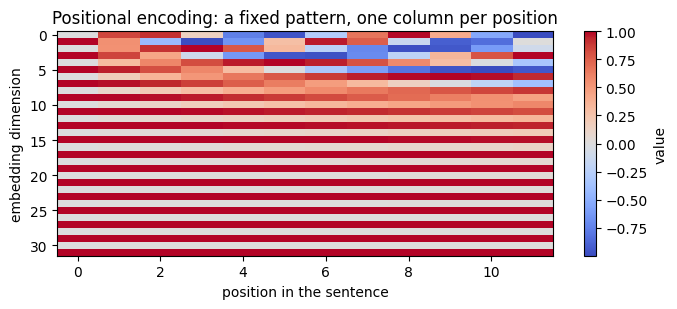

token embedding table shape: torch.Size([60, 32]) (one row per vocabulary word)
vector for 'mountain' (first 6 numbers): [-1.    -0.088  0.018  0.447 -1.301 -0.879]


In [6]:
def sinusoidal_pe(maxlen, d):
    # Build the classic sinusoidal positional encoding: one row per position, d columns.
    # Even columns get sine, odd columns get cosine, at geometrically increasing wavelengths.
    pos = torch.arange(maxlen)[:, None].float()                    # position index, shape [maxlen,1]
    i = torch.arange(d)[None, :].float()                           # column index, shape [1,d]
    angle = pos / (10000 ** (2 * (i // 2) / d))                    # angle for each (position, column)
    pe = torch.zeros(maxlen, d)                                    # output table
    pe[:, 0::2] = torch.sin(angle[:, 0::2])                        # even columns: sine
    pe[:, 1::2] = torch.cos(angle[:, 1::2])                        # odd columns: cosine
    return pe

pe_table = sinusoidal_pe(MAXLEN, D_MODEL)             # one fixed table, shared by every sentence
print("positional encoding table shape:", pe_table.shape)

plt.figure(figsize=(7, 3.2))                                          # a wide, short figure
plt.imshow(pe_table.numpy().T, aspect="auto", cmap="coolwarm")        # transpose: dimensions down the y axis
plt.xlabel("position in the sentence"); plt.ylabel("embedding dimension")
plt.title("Positional encoding: a fixed pattern, one column per position")
plt.colorbar(label="value"); plt.tight_layout(); plt.show()           # colour key, then draw

# A learned token embedding for comparison: same shape of object, but random until trained.
demo_embed = nn.Embedding(VOCAB_SIZE, D_MODEL, padding_idx=vocab[PAD])   # the lookup table itself
print("token embedding table shape:", demo_embed.weight.shape, "(one row per vocabulary word)")
print("vector for 'mountain' (first 6 numbers):",
      demo_embed.weight[vocab["mountain"]][:6].detach().numpy().round(3))

In [7]:
# The same table as an interactive 3D surface, so you can see the sine/cosine waves directly.
if HAVE_PLOTLY:                                                       # only if plotly is installed
    P, Dd = np.meshgrid(np.arange(MAXLEN), np.arange(D_MODEL), indexing="ij")  # grid of (position, dimension)
    fig = go.Figure(data=[go.Surface(x=Dd, y=P, z=pe_table.numpy(), colorscale="RdBu")])  # height = PE value
    fig.update_layout(title="Positional encoding surface (rotate me)", height=450,
                      scene=dict(xaxis_title="dimension", yaxis_title="position", zaxis_title="value"))
    fig.show()                                                        # drag to rotate, scroll to zoom
else:
    print("Plotly not available - the 2D heatmap above is enough.")   # 2D fallback, nothing is lost

Plotly not available - the 2D heatmap above is enough.


## Section 4. Self-attention, from scratch

Self-attention lets every token build a new representation of itself by taking a **weighted mix** of
every other token in the sentence. For each token we compute a **query** (what am I looking for), a
**key** (what do I offer), and a **value** (what do I contribute if picked). The attention weight
between two tokens is how well one's query matches the other's key:

`Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V`

The `softmax` turns raw scores into weights that sum to 1 for each token, so a token's new
representation is a proper weighted average of every value vector, including its own. Padding
positions are masked out (set to `-inf` before the softmax) so they get **zero** attention weight and
never leak into a real token's representation.

In [8]:
class SelfAttention(nn.Module):
    # Single-head scaled dot-product self-attention.
    def __init__(self, d_model):
        super().__init__()
        self.q = nn.Linear(d_model, d_model)          # learned query projection
        self.k = nn.Linear(d_model, d_model)          # learned key projection
        self.v = nn.Linear(d_model, d_model)          # learned value projection
        self.scale = d_model ** 0.5                   # sqrt(d_k), keeps scores in a sane range

    def forward(self, x, pad_mask):
        # x: [batch, seq, d_model]. pad_mask: [batch, seq] True where the token is real (not padding).
        q, k, v = self.q(x), self.k(x), self.v(x)                      # project into query/key/value
        scores = (q @ k.transpose(-2, -1)) / self.scale                # [batch, seq, seq] raw scores
        mask = pad_mask[:, None, :].expand_as(scores)                  # broadcast: mask KEY positions
        scores = scores.masked_fill(~mask, float("-inf"))              # padding keys get -inf score
        weights = scores.softmax(dim=-1)                               # turn scores into a distribution
        out = weights @ v                                              # weighted mix of value vectors
        return out, weights

# Try it on one real sentence: encode it, run attention, and look at the weights.
demo_sentence = "the rocky mountain has strong wind"
demo_ids = torch.tensor([encode(demo_sentence)])                       # [1, MAXLEN]
demo_mask = (demo_ids != vocab[PAD])                                   # [1, MAXLEN], True = real token
demo_x = demo_embed(demo_ids) + pe_table[None, :MAXLEN]                # token embedding (Section 3) + position
attn = SelfAttention(D_MODEL)
demo_out, demo_w = attn(demo_x, demo_mask)
print("attention weights shape:", demo_w.shape, "(batch, query position, key position)")

attention weights shape: torch.Size([1, 12, 12]) (batch, query position, key position)


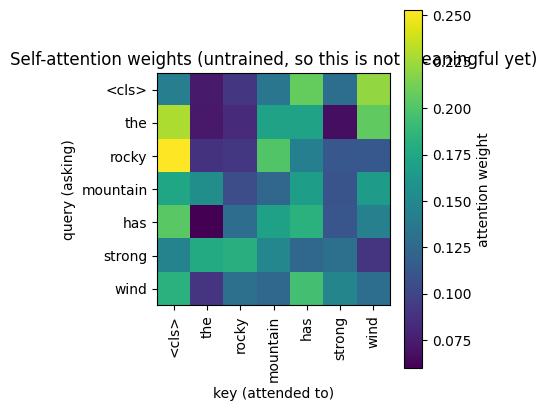

each row sums to 1 (a proper weighted average): [1. 1. 1. 1. 1. 1. 1.]


In [9]:
# Visualise the attention weights for the real (non-padding) tokens of the demo sentence.
n_real = int(demo_mask.sum().item())                    # how many real tokens (incl. <cls>)
labels = ([CLS] + demo_sentence.split())[:n_real]        # matching labels for the plot
w = demo_w[0, :n_real, :n_real].detach().numpy()         # crop away the padding rows/columns

plt.figure(figsize=(4.5, 4.5))                                    # square figure for a square matrix
plt.imshow(w, cmap="viridis")                                     # brighter cell = more attention
plt.xticks(range(n_real), labels, rotation=90); plt.yticks(range(n_real), labels)   # word labels on both axes
plt.xlabel("key (attended to)"); plt.ylabel("query (asking)")     # rows ask, columns are asked
plt.title("Self-attention weights (untrained, so this is not meaningful yet)")
plt.colorbar(label="attention weight"); plt.tight_layout(); plt.show()
print("each row sums to 1 (a proper weighted average):", w.sum(axis=1).round(3))

## Section 5. Multi-head attention

One attention pattern can only capture one kind of relationship at a time. **Multi-head attention**
runs several smaller attention computations (heads) in parallel, each with its own query/key/value
projections, then concatenates their outputs. Different heads are free to specialise, one might learn
to attend to the previous word, another to the sentence's subject, and so on. We will see this later
once the model is trained; for now, we build the mechanism.

In [10]:
class MultiHeadAttention(nn.Module):
    # h independent attention heads, run in parallel, then combined by a final linear layer.
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must divide evenly by n_heads"
        self.h = n_heads; self.dk = d_model // n_heads               # width of each head
        self.q = nn.Linear(d_model, d_model); self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model); self.o = nn.Linear(d_model, d_model)  # combine heads

    def forward(self, x, pad_mask):
        B, L, D = x.shape
        # Split D_MODEL into (h, dk) and move the head dimension next to batch, so each head is
        # a separate slice we can matrix-multiply independently.
        q = self.q(x).view(B, L, self.h, self.dk).transpose(1, 2)    # [B, h, L, dk]
        k = self.k(x).view(B, L, self.h, self.dk).transpose(1, 2)
        v = self.v(x).view(B, L, self.h, self.dk).transpose(1, 2)
        scores = (q @ k.transpose(-2, -1)) / (self.dk ** 0.5)        # [B, h, L, L]
        mask = pad_mask[:, None, None, :].expand_as(scores)          # same padding mask, every head
        scores = scores.masked_fill(~mask, float("-inf"))
        weights = scores.softmax(dim=-1)                             # [B, h, L, L]
        out = (weights @ v).transpose(1, 2).reshape(B, L, D)         # merge heads back into D_MODEL
        return self.o(out), weights                                  # weights kept for visualising later

mha_demo = MultiHeadAttention(D_MODEL, N_HEADS)
_, w_multi = mha_demo(demo_x, demo_mask)
print("multi-head weights shape:", w_multi.shape, "(batch, head, query, key)")

multi-head weights shape: torch.Size([1, 2, 12, 12]) (batch, head, query, key)


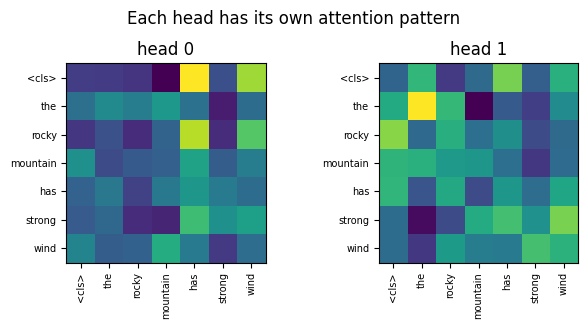

In [11]:
# Show each head's attention pattern side by side (still untrained, just to see the shape of things).
fig, ax = plt.subplots(1, N_HEADS, figsize=(3.2 * N_HEADS, 3.2))   # one subplot per head
if N_HEADS == 1: ax = [ax]                                         # keep indexing uniform if there is one head
for h in range(N_HEADS):                                           # draw each head in turn
    wh = w_multi[0, h, :n_real, :n_real].detach().numpy()          # crop this head's weights to real tokens
    ax[h].imshow(wh, cmap="viridis")                               # same colour scheme as before
    ax[h].set_xticks(range(n_real)); ax[h].set_xticklabels(labels, rotation=90, fontsize=7)
    ax[h].set_yticks(range(n_real)); ax[h].set_yticklabels(labels, fontsize=7)
    ax[h].set_title(f"head {h}")                                   # which head this panel is
plt.suptitle("Each head has its own attention pattern"); plt.tight_layout(); plt.show()

## Section 6. Assembling a transformer block

One transformer block wraps multi-head attention with the machinery that makes deep stacks trainable:

- a **residual connection** (`x + sublayer(x)`) around attention, so gradients have a direct path
  back through the network even if the attention layer learns something unhelpful early on,
- **layer normalisation**, which rescales each token's vector to keep activations in a stable range,
- a small **feed-forward network** applied to each token independently (the same two-layer MLP at
  every position), again wrapped in its own residual connection and layer norm.

Stacking a few of these blocks, with the embedding and positional encoding from Section 3 feeding the
first one, gives us a small transformer **encoder**.

In [12]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ln1 = nn.LayerNorm(d_model)                          # normalises before attention (pre-norm)
        self.ln2 = nn.LayerNorm(d_model)                          # normalises before the feed-forward
        self.ff = nn.Sequential(                                  # position-wise feed-forward network
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)
        )

    def forward(self, x, pad_mask):
        attn_out, weights = self.mha(self.ln1(x), pad_mask)       # attention on the normalised input
        x = x + attn_out                                          # residual connection 1
        x = x + self.ff(self.ln2(x))                              # feed-forward + residual connection 2
        return x, weights

class MiniTransformer(nn.Module):
    # Token embedding + positional encoding + a stack of transformer blocks + a final layer norm.
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, maxlen):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=vocab[PAD])
        self.register_buffer("pe", sinusoidal_pe(maxlen, d_model))    # fixed, not learned
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.ln_final = nn.LayerNorm(d_model)

    def encode(self, ids, pad_mask):
        # Returns the final per-token representations, plus every block's attention weights.
        x = self.embed(ids) + self.pe[None, :ids.shape[1]]        # token embedding + position
        all_weights = []
        for block in self.blocks:
            x, w = block(x, pad_mask); all_weights.append(w)
        return self.ln_final(x), all_weights

encoder = MiniTransformer(VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, D_FF, MAXLEN).to(device)
print(encoder)
print("total parameters:", sum(p.numel() for p in encoder.parameters()))

MiniTransformer(
  (embed): Embedding(60, 32, padding_idx=0)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (mha): MultiHeadAttention(
        (q): Linear(in_features=32, out_features=32, bias=True)
        (k): Linear(in_features=32, out_features=32, bias=True)
        (v): Linear(in_features=32, out_features=32, bias=True)
        (o): Linear(in_features=32, out_features=32, bias=True)
      )
      (ln1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
      (ln2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
      (ff): Sequential(
        (0): Linear(in_features=32, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=64, out_features=32, bias=True)
      )
    )
  )
  (ln_final): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
)
total parameters: 19072


## Section 7. Training with masked-token prediction

To train the encoder without any labels, we use the same trick as BERT: **masked language modelling
(MLM)**. Take a real sentence, hide a fraction of its words behind a `<mask>` token, and train the
model to predict the hidden words from context. A linear layer (the **MLM head**) turns each token's
final representation back into a distribution over the vocabulary.

This is exactly the "pretraining" step: no labels are needed, only raw sentences, and the model learns
generally useful representations of words and context that later get reused for a real task.

In [13]:
# Build the pretraining sentence pool: all three topics, unlabelled (labels are not used here).
pretrain_sentences = [gen_topic_sentence(c, rng) for c in range(3) for _ in range(N_PER_TOPIC)]
random.shuffle(pretrain_sentences)                                            # mix the three topics together
X_pre = torch.tensor([encode(s) for s in pretrain_sentences], device=device)   # [N, MAXLEN] token ids
pad_pre = (X_pre != vocab[PAD])                                               # True where a token is real
print(f"pretraining sentences: {len(pretrain_sentences)}  |  example: '{pretrain_sentences[0]}'")

mlm_head = nn.Linear(D_MODEL, VOCAB_SIZE).to(device)      # maps a token vector back to vocabulary logits

pretraining sentences: 450  |  example: 'the steep mountain has strong wind'


In [14]:
mlm_loss_hist = []                                        # loss per epoch (for the curve)
_enc_path = os.path.join(MODELS_DIR, "mini_transformer.pt")
_head_path = os.path.join(MODELS_DIR, "mlm_head.pt")

if TRAIN_FROM_SCRATCH or not (os.path.exists(_enc_path) and os.path.exists(_head_path)):
    params = list(encoder.parameters()) + list(mlm_head.parameters())
    opt = torch.optim.Adam(params, lr=3e-3)
    N = X_pre.shape[0]
    for epoch in range(MLM_EPOCHS):
        perm = torch.randperm(N, device=device); tot = 0.0
        for i in range(0, N, BATCH):
            idx = perm[i:i + BATCH]
            inp = X_pre[idx].clone(); m = pad_pre[idx]
            labels = torch.full_like(inp, -100)                          # -100 = ignored by the loss
            maskable = m & (inp != vocab[CLS])                           # never mask padding or <cls>
            chosen = maskable & (torch.rand(inp.shape, device=device) < 0.3)   # mask ~30% of real words
            labels[chosen] = inp[chosen]                                 # the label is the ORIGINAL word
            inp[chosen] = vocab[MASK]                                    # hide it behind <mask>
            reps, _ = encoder.encode(inp, m)                             # encode the masked sentence
            logits = mlm_head(reps)                                      # predict a word at every position
            loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), labels.reshape(-1), ignore_index=-100)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(idx)
        mlm_loss_hist.append(tot / N)
        if (epoch + 1) % 15 == 0:
            print(f"epoch {epoch+1:3d}/{MLM_EPOCHS}  loss {mlm_loss_hist[-1]:.4f}")
    save_model(encoder, "mini_transformer.pt"); save_model(mlm_head, "mlm_head.pt")
else:
    load_model(encoder, "mini_transformer.pt"); load_model(mlm_head, "mlm_head.pt")
encoder.eval(); mlm_head.eval();

loaded models/mini_transformer.pt
loaded models/mlm_head.pt


In [15]:
# If we trained, show the loss curve. It should fall then flatten.
if mlm_loss_hist:                                                  # empty when we loaded weights instead
    plt.figure(figsize=(6, 3)); plt.plot(mlm_loss_hist)             # one point per epoch
    plt.xlabel("epoch"); plt.ylabel("masked-token cross-entropy"); plt.title("MLM pretraining loss")
    plt.grid(True, alpha=0.3); plt.show()                           # a light grid makes it easier to read
else:
    print("Loaded pretrained weights - no fresh loss curve to plot.")

Loaded pretrained weights - no fresh loss curve to plot.


In [16]:
def mlm_probe(sentence, mask_position):
    # Hide the word at mask_position, run the encoder + MLM head, and report the top 5 guesses.
    ids = torch.tensor([encode(sentence)], device=device)         # [1, MAXLEN] token ids
    pad = (ids != vocab[PAD])                                     # True where the token is real
    true_word = inv_vocab[ids[0, mask_position].item()]           # remember the word we are hiding
    masked = ids.clone()                                          # do not modify the original ids
    masked[0, mask_position] = vocab[MASK]                        # replace that word with <mask>
    with torch.no_grad():                                         # inference only, no gradients
        reps, weights = encoder.encode(masked, pad)               # final token representations
        logits = mlm_head(reps)                                   # vocabulary scores at every position
    top5 = logits[0, mask_position].topk(5).indices.tolist()      # the 5 highest-scoring word ids
    print("sentence :", decode(masked[0].tolist()))               # show the sentence with the hole
    print("true word:", true_word, "| top 5 guesses:", [inv_vocab[i] for i in top5])
    return weights                                                # attention weights, reused below

# Probe 1: a word the context fully determines. "farmers plant ... in the <adj> ___" can only end
# in "farmland", so a model that has learned the template should get this right.
print("Probe 1 - context determines the answer")
attn_weights = mlm_probe("farmers plant wheat in the rich farmland", 7)

# Probe 2: a word the context CANNOT determine. The mountain and coast templates are identical
# ("the <adj> ___ has <feature>"), so both words fit and the best the model can do is split its
# probability between them. Seeing that in the top-5 list is the point of this probe.
print()
print("Probe 2 - context is genuinely ambiguous (mountain and coast share a template)")
_ = mlm_probe("the rocky mountain has strong wind", 3)

Probe 1 - context determines the answer
sentence : <cls> farmers plant wheat in the rich <mask>
true word: farmland | top 5 guesses: ['farmland', 'green', 'plant', 'waves', 'rice']

Probe 2 - context is genuinely ambiguous (mountain and coast share a template)
sentence : <cls> the rocky <mask> has strong wind
true word: mountain | top 5 guesses: ['mountain', 'coast', 'has', 'bright', 'thick']


### Looking at attention after training
The heatmaps in Sections 4 and 5 came from **untrained** layers, so their patterns meant nothing. Now
that the encoder has been trained, the same plot is worth a second look: each head has settled into
some pattern of which words it pulls information from. On a language this small the patterns are
simple (heads often lock onto the one or two words that actually identify the sentence), but the
contrast with the untrained version is the thing to notice.

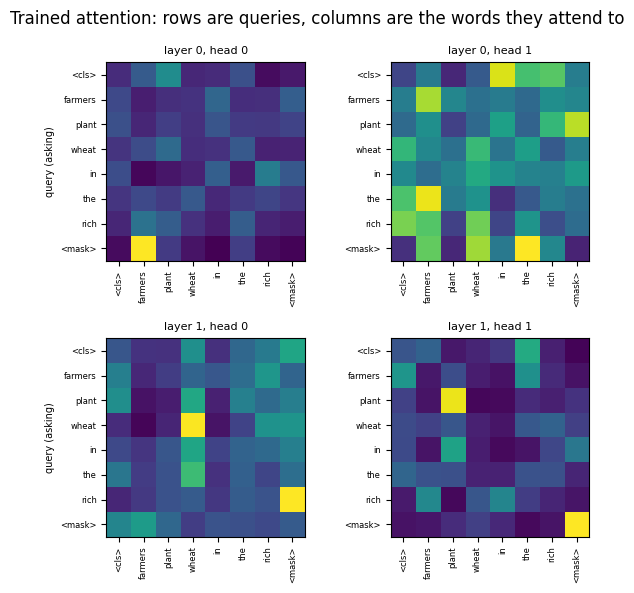

In [17]:
# attn_weights came from Probe 1 above: a list with one entry per transformer block,
# each of shape [batch, head, query, key]. Plot every head of every layer as a grid.
probe_sentence = "farmers plant wheat in the rich farmland"           # the sentence we probed
probe_labels = ([CLS] + probe_sentence.split())                       # <cls> plus each word
probe_labels[7] = "<mask>"                                            # position 7 was hidden
n_tok = len(probe_labels)                                             # how many real tokens to show

fig, ax = plt.subplots(N_LAYERS, N_HEADS, figsize=(3.0 * N_HEADS, 3.0 * N_LAYERS), squeeze=False)
for layer in range(N_LAYERS):                                         # one row per transformer block
    for h in range(N_HEADS):                                          # one column per head
        wl = attn_weights[layer][0, h, :n_tok, :n_tok].cpu().numpy()  # crop away padding
        a = ax[layer][h]                                              # the subplot to draw on
        a.imshow(wl, cmap="viridis", vmin=0)                          # attention weights as an image
        a.set_xticks(range(n_tok)); a.set_xticklabels(probe_labels, rotation=90, fontsize=6)
        a.set_yticks(range(n_tok)); a.set_yticklabels(probe_labels, fontsize=6)
        a.set_title(f"layer {layer}, head {h}", fontsize=8)           # which head this is
        if h == 0: a.set_ylabel("query (asking)", fontsize=7)         # label only the left column
plt.suptitle("Trained attention: rows are queries, columns are the words they attend to")
plt.tight_layout(); plt.show()

## Section 8. Loading the pretrained transformer and modifying it for classification

The encoder above is now a **pretrained transformer**: it was trained on unlabelled sentences and has
learned generally useful representations of this little language. To use it for a real task, we
**modify** it:

1. **Discard** the MLM head (it only knows how to predict hidden words, which is not our new task).
2. **Attach a new head**: a small linear layer that reads the `<cls>` token's final representation
   (a summary of the whole sentence) and outputs a score per class.
3. **Fine-tune**: train the new head (and, optionally, the encoder itself) on a small labelled
   dataset for the new task.

Here the new task is **topic classification**: mountain, farmland, or coast. Since we generate the
sentences ourselves, generating labels is free.

One practical detail that matters more than it looks: fine-tuning **changes the encoder's weights**.
If we fine-tuned `encoder` itself, it would stop being the pretrained model the moment this section
finished, and Part 2 would then be starting from a topic-classifier, not from the pretrained
transformer. So we fine-tune a **copy** and leave `encoder` untouched. This is the same reason you
keep a pristine copy of any downloaded checkpoint in a real project.

In [18]:
class ClassifierHead(nn.Module):
    # Reads the <cls> position's final representation and predicts a class.
    def __init__(self, d_model, n_classes):
        super().__init__()
        self.linear = nn.Linear(d_model, n_classes)
    def forward(self, cls_representation):
        return self.linear(cls_representation)

def classify_batch(enc, head, ids, pad_mask):
    # Shared helper: encode a batch, pool the <cls> token, and predict class scores.
    reps, _ = enc.encode(ids, pad_mask)         # [batch, seq, d_model]
    pooled = reps[:, 0]                         # the <cls> position is always index 0 (see encode())
    return head(pooled)

# Build a labelled dataset: topic sentences with their true class (0=mountain, 1=farmland, 2=coast).
topic_sentences, topic_labels = [], []                    # sentences and their class ids
for c in range(3):                                        # one loop per class
    for _ in range(N_PER_TOPIC):                          # N_PER_TOPIC sentences each
        topic_sentences.append(gen_topic_sentence(c, rng)); topic_labels.append(c)

X_topic = torch.tensor([encode(s) for s in topic_sentences])   # [N, MAXLEN] token ids
y_topic = torch.tensor(topic_labels)                      # [N] class labels
perm = torch.randperm(len(y_topic))                       # shuffle before splitting
X_topic, y_topic = X_topic[perm], y_topic[perm]           # apply the same shuffle to both
split = int(0.8 * len(y_topic))                           # 80% train, 20% test
Xtr, ytr = X_topic[:split].to(device), y_topic[:split].to(device)   # training half
Xte, yte = X_topic[split:].to(device), y_topic[split:].to(device)   # held-out half
print(f"topic dataset: {len(ytr)} train, {len(yte)} test, classes {TOPIC_NAMES}")

topic dataset: 360 train, 90 test, classes ['mountain', 'farmland', 'coast']


In [19]:
topic_encoder = copy.deepcopy(encoder)                               # a COPY, so `encoder` stays pretrained
topic_head = ClassifierHead(D_MODEL, n_classes=3).to(device)         # the new head, freshly initialised
topic_encoder.train(); topic_head.train()                            # training mode (habit worth keeping)
opt = torch.optim.Adam(list(topic_encoder.parameters()) + list(topic_head.parameters()), lr=1e-3)

for epoch in range(CLF_EPOCHS):                                      # one pass over the data per epoch
    perm = torch.randperm(Xtr.shape[0], device=device); tot = 0.0    # reshuffle each epoch
    for i in range(0, Xtr.shape[0], BATCH):                          # step through mini-batches
        idx = perm[i:i + BATCH]                                      # indices for this batch
        xb, yb = Xtr[idx], ytr[idx]; mb = (xb != vocab[PAD])         # inputs, labels, padding mask
        logits = classify_batch(topic_encoder, topic_head, xb, mb)   # encode, pool <cls>, classify
        loss = F.cross_entropy(logits, yb)                           # standard classification loss
        opt.zero_grad(); loss.backward(); opt.step()                 # backprop and update
        tot += loss.item() * len(idx)                                # running loss, weighted by batch size
    if (epoch + 1) % 10 == 0:                                        # progress every 10 epochs
        print(f"epoch {epoch+1:3d}/{CLF_EPOCHS}  loss {tot/Xtr.shape[0]:.4f}")

topic_encoder.eval(); topic_head.eval()                              # back to evaluation mode
with torch.no_grad():                                                # no gradients needed for testing
    test_logits = classify_batch(topic_encoder, topic_head, Xte, (Xte != vocab[PAD]))
    acc = (test_logits.argmax(-1) == yte).float().mean().item()      # fraction predicted correctly
print(f"topic classifier test accuracy: {acc:.3f}")

# Proof that the copy worked: the fine-tuned copy's weights moved, the pretrained original's did not.
_moved = any(not torch.equal(a, b) for a, b in zip(encoder.state_dict().values(),
                                                   topic_encoder.state_dict().values()))
print("topic_encoder differs from the pretrained encoder:", _moved, "(so `encoder` is still pretrained)")

epoch  10/25  loss 0.0094
epoch  20/25  loss 0.0041
topic classifier test accuracy: 1.000
topic_encoder differs from the pretrained encoder: True (so `encoder` is still pretrained)


### Recognising the pattern
Notice the shape of what just happened: **pretrain** the encoder on unlabelled text (Section 7), then
**fine-tune** a small new head on a labelled task (this section). Real pretrained transformers (BERT,
GPT, and the rest) are used the same way, just at a much larger scale. Part 2 asks you to repeat this
exact recipe on a different task.

## Section 9. Recap

You have now built a transformer from the ground up:

- **token embeddings** and **sinusoidal positional encoding**,
- **self-attention**, from a single head to a visualised **multi-head** version,
- a full **transformer block** with residual connections, layer normalisation, and a feed-forward layer,
- **masked-token-prediction (MLM)** pretraining, with no labels needed, and a look at what attention
  settles into once the model is actually trained,
- **loading a pretrained transformer and modifying it**: copy it, swap the head, fine-tune, done.

The honest limits: this is a tiny model on a tiny made-up language, so do not expect BERT-level
results, and the templates repeat often enough that train and test sets overlap. The mechanics,
though, are exactly the same ones real transformers use.

The pretrained encoder is saved in `models/` (`mini_transformer.pt`, `mlm_head.pt`), so it can be
reloaded without retraining. On to Part 2.

---
# Part 2 - Individual Exercise (about 30 to 45 minutes)

Work through this on your own. There are hints but **no worked solution**. Reuse everything from
Part 1 (`encoder`, `ClassifierHead`, `classify_batch`, `gen_condition_sentence`, `encode`, `vocab`,
`device`, `MAXLEN`, `copy`), once you have run Part 1.

## The task: a new classification task, same recipe
Section 8 fine-tuned the pretrained encoder to classify **topic** (mountain / farmland / coast). Now
repeat the same recipe for a **different** task: classifying the **condition** of a piece of land, as
drought, flood, or healthy, using `gen_condition_sentence(cls, rng)` (already defined in Part 1,
classes 0=drought, 1=flood, 2=healthy).

**Task 1, build the labelled dataset (about 10 min).**
Generate, say, 60 sentences per class with `gen_condition_sentence`, encode them, split into train and
test (80/20 is fine), and check the class balance.

**Task 2, attach a fresh classifier head (about 5 min).**
Make a **new** `ClassifierHead(D_MODEL, n_classes=3)`. Do not reuse `topic_head`, it was trained for a
different task with different classes.

**Task 3, fine-tune and evaluate (about 15 min).**
Make your own copy of the pretrained encoder first (`cond_encoder = copy.deepcopy(encoder)`), exactly
as Section 8 did, then write the training loop (you have seen it twice now, in Section 7 and
Section 8), train for a reasonable number of epochs, and report test accuracy.

**Task 4 (stretch), freeze vs fine-tune (about 10 min).**
Take a **second fresh copy** of `encoder`, **freeze** it
(`for p in frozen_encoder.parameters(): p.requires_grad = False`) so only a new head trains, and
compare test accuracy against your fine-tuned version from Task 3. Which does better here, and why
might that be, given how small this dataset is?

### Hints
- Reuse `classify_batch(enc, head, ids, pad_mask)` from Section 8, it works for any encoder and head.
- Both comparisons in Task 4 must start from the **same** pretrained weights, which is exactly why you
  copy `encoder` rather than training it in place. If you fine-tuned `encoder` itself in Task 3, your
  "frozen" encoder in Task 4 would already have been trained on this task, and the comparison would be
  meaningless. Check your two encoders really are different objects.
- The optimiser should be built from **your new head's** parameters (plus your encoder copy's, if you
  are fine-tuning it): `torch.optim.Adam(list(cond_encoder.parameters()) + list(head.parameters()), lr=1e-3)`.
- For the frozen version, only pass `head.parameters()` to the optimiser.
- `topic_head`'s accuracy is not a fair comparison (different task, different classes), so evaluate
  your new head only against itself (frozen vs fine-tuned).
- Remember the caveat from Section 2: the condition templates make only a couple of dozen distinct
  sentences for two of the three classes, so your train and test sets will overlap and accuracy will
  look very high. Say so in your write-up rather than treating the number at face value.

### What to submit
Your filled-in cells (runnable top to bottom) plus two or three sentences answering: did fine-tuning
the whole encoder help over just training the head, and why do you think that is?

### Task 1 (your code below)

In [20]:
# TODO Task 1: generate condition sentences with gen_condition_sentence, encode, split train/test.

### Task 2 (your code below)

In [21]:
# TODO Task 2: create a fresh ClassifierHead(D_MODEL, n_classes=3) for the condition task.

### Task 3 (your code below)

In [22]:
# TODO Task 3: copy the pretrained encoder, write the fine-tuning loop, report test accuracy.

### Stretch (optional, your code below)

In [23]:
# TODO (optional): take a second fresh copy of encoder, freeze it, train only a new head, compare.